# Predicting EGFR Driver Mutations from Lung Adenocarcinoma Slides

**The problem:** can a model predict whether a lung adenocarcinoma carries an EGFR driver mutation from the H&E biopsy image alone, before genomic sequencing comes back? EGFR status decides whether a patient is a candidate for targeted therapy, so a fast image-based signal could help decide which cases to prioritize for testing.

**Data:** TCGA-LUAD diagnostic whole-slide images from the NIH Genomic Data Commons (open access), paired with mutation calls from the cBioPortal TCGA-LUAD mutation table.

**Model:** a CLAM-style gated attention-MIL model on patch embeddings from a pathology foundation model.

**Why this project:** after my prostate baseline, I wanted a harder and more clinically relevant target: a genetic change instead of something a pathologist can see directly.

This notebook also prepares the data for my next notebook, where an agent decides which regions of the slide to zoom into. That is why it caches embeddings at two magnifications.

**How I built it:** I chose the design and ran every cell. Most of the code in this notebook was written with Claude, based on the design I described, and I went through each part so I can explain what it does and why.

---
## Setup

In [1]:
!pip install -q openslide-python openslide-bin

In [2]:
import os, json, time, zlib, random

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

import openslide
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Two colors used for every plot: blue = wild-type, orange = EGFR-mutant
C_WT, C_MUT, C_GRAY = '#2a78d6', '#eb6834', '#8a8a8a'

def set_seed(seed):
    # Makes a run repeatable: same seed, same numbers
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

Using device: cuda


In [3]:
# ---------------- Config: every setting in one place ----------------

# Input: the cBioPortal TCGA-LUAD mutation table (attached as a Kaggle dataset)
MUTATION_PATH = '/kaggle/input/datasets/soaadhamood34/tcga-luad-mutation-data/data_mutations.txt'
assert os.path.exists(MUTATION_PATH), 'Attach my cBioPortal TCGA-LUAD mutation dataset with Add Input'

# Optional fallback if the GDC API is not reachable: a GDC manifest of ALL
# TCGA-LUAD diagnostic slides (download it from the GDC portal).
FULL_MANIFEST_PATH = None

WORK = '/kaggle/working'
SLIDE_TMP = f'{WORK}/slides_tmp'   # slides are downloaded here, then deleted
CACHE_DIR = f'{WORK}/cache_lung'     # one .pt file of embeddings per slide
THUMB_DIR = f'{WORK}/thumbs'       # one small thumbnail per slide (for heatmaps)
MODEL_DIR = f'{WORK}/models'
for d in (SLIDE_TMP, CACHE_DIR, THUMB_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

# Dataset size (mutant cases are enriched on purpose, see Part 2)
N_POS = 25
N_NEG = 50
SELECTION_SEED = 0

# Tiling
TILE = 256            # tile size in pixels, at the magnification it is read at
LOW_MAG = 5           # "look at the whole slide" magnification
HIGH_MAG = 20         # "zoom in" magnification
MIN_TISSUE = 0.5      # a tile or region must be at least 50% tissue
GRAY_CUTOFF = 220     # brighter than this (out of 255) = empty glass
MAX_REGIONS = 1000    # cap on 5x regions per slide
HI_PER_REGION = 4     # 20x tiles sampled inside each 5x region
KEEP_SLIDES = False   # True keeps the .svs files (needs a lot of disk)

# Encoder: 'phikon' (pathology-pretrained) or 'resnet18' (ImageNet)
ENCODER_NAME = 'phikon'

# Training and evaluation
N_FOLDS = 5
SEED = 0              # fixes all randomness, so every run gives the same numbers
EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
TILES_PER_STEP = 512  # random tiles per slide per training step

---
# Part 1: Building Clean EGFR Labels

The simplest approach would be to label a patient EGFR-mutant if the mutation table has **any** EGFR row. That would be wrong in two ways:

1. **Not every EGFR mutation matters.** Many are silent (they don't change the protein) or are passenger mutations with no known effect. The mutations that drive the cancer and make a patient eligible for EGFR-targeted drugs are a known, small set.
2. **Missing is not negative.** A patient who was never sequenced does not appear in the mutation table at all. Treating them as "wild-type" would be a guess, not a label.

**My label rules:**

| Label | Rule |
|---|---|
| **1 (EGFR driver)** | L858R, L861Q, S768I, T790M or G719X point mutations; in-frame deletions in exon 19; in-frame insertions in exon 20 |
| **0 (wild-type)** | Sequenced patient with no EGFR mutation, or only silent / non-coding EGFR changes |
| **Left out** | Sequenced patient with some other EGFR mutation (unclear effect), and patients who were never sequenced |

Leaving out the unclear cases makes the dataset smaller, but every label that remains means what I say it means.

In [4]:
mut = pd.read_csv(MUTATION_PATH, sep='\t', comment='#', low_memory=False)

# Keep primary tumor samples only (sample type '01' in the TCGA barcode)
mut['Tumor_Sample_Barcode'] = mut['Tumor_Sample_Barcode'].astype(str)
mut = mut[mut['Tumor_Sample_Barcode'].str[13:15] == '01'].copy()

# A TCGA patient ID is the first 12 characters: TCGA-38-4631-01 -> TCGA-38-4631
mut['patient'] = mut['Tumor_Sample_Barcode'].str[:12]

# Every patient who appears in the table was sequenced
sequenced_patients = set(mut['patient'])
print('Sequenced patients:', len(sequenced_patients))

Sequenced patients: 562


### A first look at the mutation table

Before building labels, I want to understand what this table actually contains. Each row is **one DNA change found in one patient's tumor**, so every patient appears many times. There is no "EGFR-positive" column: I have to build the label myself from these rows.

In [5]:
print(f"Rows (one per mutation found): {len(mut):,}")
print(f"Columns: {mut.shape[1]}")
print(f"Patients: {mut['patient'].nunique()}")

# The five columns I actually use
display(mut[['patient', 'Hugo_Symbol', 'Variant_Classification', 'HGVSp_Short', 'EXON']].head(10))

Rows (one per mutation found): 225,653
Columns: 115
Patients: 562


,patient,Hugo_Symbol,Variant_Classification,HGVSp_Short,EXON
0,TCGA-05-4244,CPN1,Missense_Mutation,p.H366D,7/9
1,TCGA-05-4244,MKI67,Silent,p.N2401=,13/15
2,TCGA-05-4244,NEBL,In_Frame_Del,p.S730_V731del,22/28
3,TCGA-05-4244,ANKRD30BP3,RNA,p.*99*,8/11
4,TCGA-05-4244,ERCC6,Silent,p.S1381=,21/21
5,TCGA-05-4244,DIP2C,Splice_Site,p.X29_splice,.
6,TCGA-05-4244,HECTD2,Missense_Mutation,p.P121Q,3/21
7,TCGA-05-4244,TLL2,Silent,p.A183=,5/21
8,TCGA-05-4244,ATM,Missense_Mutation,p.K2413Q,49/63
9,TCGA-05-4244,USP28,Splice_Region,p.X304_splice,.


Mutations per patient: median 278, smallest 2, largest 2999


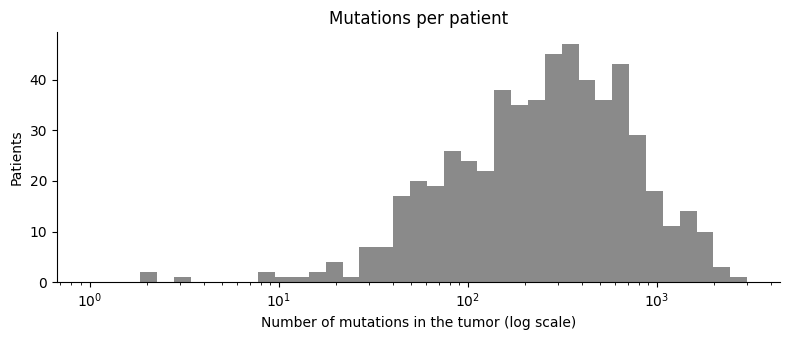

In [6]:
# How many mutations does each patient's tumor have?
per_patient = mut.groupby('patient').size()
print(f'Mutations per patient: median {per_patient.median():.0f}, '
      f'smallest {per_patient.min()}, largest {per_patient.max()}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(per_patient, bins=np.logspace(0, np.log10(per_patient.max() + 1), 40), color=C_GRAY)
ax.set_xscale('log')
ax.set_xlabel('Number of mutations in the tumor (log scale)'); ax.set_ylabel('Patients')
ax.set_title('Mutations per patient')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

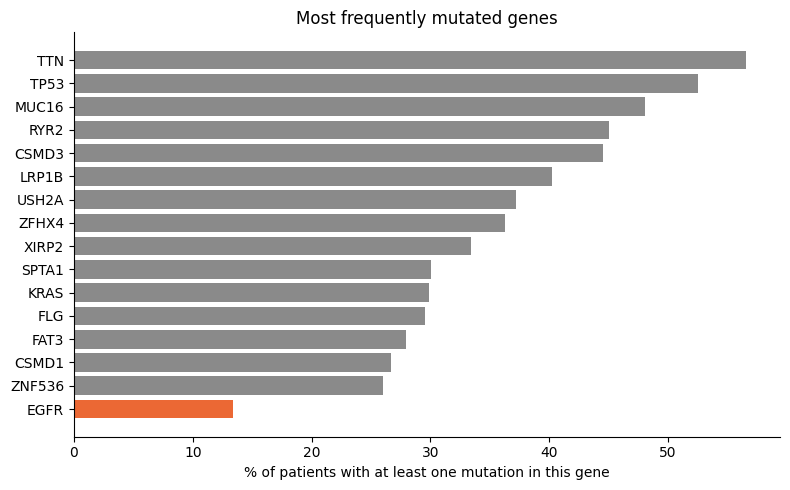

EGFR is mutated (any change) in 13.3% of patients


In [7]:
# Which genes are mutated in the most patients? (EGFR in orange)
n_patients = mut['patient'].nunique()
gene_patients = mut.drop_duplicates(['patient', 'Hugo_Symbol'])['Hugo_Symbol'].value_counts()
top = gene_patients.head(15)
if 'EGFR' not in top.index:
    top = pd.concat([top, gene_patients[['EGFR']]])
share = 100 * top / n_patients

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(share.index[::-1], share.values[::-1],
        color=[C_MUT if g == 'EGFR' else C_GRAY for g in share.index[::-1]])
ax.set_xlabel('% of patients with at least one mutation in this gene')
ax.set_title('Most frequently mutated genes')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f"EGFR is mutated (any change) in {100 * gene_patients.get('EGFR', 0) / n_patients:.1f}% of patients")

In [8]:
# What kinds of changes are in the table?
print('All mutations, by type:')
print(mut['Variant_Classification'].value_counts().head(10))

# And just the EGFR rows
egfr_rows = mut[mut['Hugo_Symbol'].str.upper() == 'EGFR']
print(f"\nEGFR rows: {len(egfr_rows)} | patients with any EGFR change: {egfr_rows['patient'].nunique()}")
print('\nEGFR changes, by type:')
print(egfr_rows['Variant_Classification'].value_counts())
print('\nMost common EGFR protein changes:')
print(egfr_rows['HGVSp_Short'].value_counts().head(10))

All mutations, by type:
Variant_Classification
Missense_Mutation    133460
Silent                45833
Nonsense_Mutation     11075
3'UTR                  8197
5'UTR                  4813
Splice_Site            4497
RNA                    4058
Intron                 4047
Frame_Shift_Del        3936
Splice_Region          2267
Name: count, dtype: int64

EGFR rows: 91 | patients with any EGFR change: 75

EGFR changes, by type:
Variant_Classification
Missense_Mutation    53
In_Frame_Del         26
In_Frame_Ins          3
Silent                3
Nonsense_Mutation     2
Splice_Region         1
Frame_Shift_Del       1
Intron                1
3'UTR                 1
Name: count, dtype: int64

Most common EGFR protein changes:
HGVSp_Short
p.L858R               23
p.E746_A750del        16
p.L861Q                3
p.E709_T710delinsD     3
p.S768I                2
p.L747_T751del         2
p.L747_A750delinsP     2
p.L62R                 2
p.T790M                2
p.G719A                2
Name: coun

In [9]:
HOTSPOTS = {'p.L858R', 'p.L861Q', 'p.S768I', 'p.T790M',
            'p.G719A', 'p.G719S', 'p.G719C', 'p.G719D'}
SILENT_LIKE = {'Silent', "3'UTR", "5'UTR", 'Intron', "3'Flank", "5'Flank", 'RNA', 'IGR', 'Splice_Region'}

egfr = mut[mut['Hugo_Symbol'].str.upper() == 'EGFR'].copy()
exon_col = 'EXON' if 'EXON' in egfr.columns else 'Exon_Number'
egfr['exon'] = egfr[exon_col].astype(str).str.split('/').str[0]   # '19/28' -> '19'

def classify_egfr_variant(row):
    protein_change = str(row['HGVSp_Short'])
    variant_type = row['Variant_Classification']
    if protein_change in HOTSPOTS:
        return 'driver'
    if variant_type == 'In_Frame_Del' and row['exon'] == '19':
        return 'driver'
    if variant_type == 'In_Frame_Ins' and row['exon'] == '20':
        return 'driver'
    if variant_type in SILENT_LIKE:
        return 'silent'
    return 'other'

egfr['egfr_class'] = egfr.apply(classify_egfr_variant, axis=1)

driver_patients = set(egfr.loc[egfr['egfr_class'] == 'driver', 'patient'])
other_patients = set(egfr.loc[egfr['egfr_class'] == 'other', 'patient']) - driver_patients

def patient_label(p):
    if p in driver_patients:
        return 1
    if p in other_patients:
        return -1          # unclear, left out
    return 0

patients = pd.DataFrame({'patient': sorted(sequenced_patients)})
patients['egfr_label'] = patients['patient'].apply(patient_label)

print('Patients with any EGFR row at all:', egfr['patient'].nunique())
summary = patients['egfr_label'].map({1: 'EGFR driver (1)', 0: 'wild-type (0)', -1: 'unclear, left out'}).value_counts()
print(summary)

Patients with any EGFR row at all: 75
egfr_label
wild-type (0)        493
EGFR driver (1)       55
unclear, left out     14
Name: count, dtype: int64


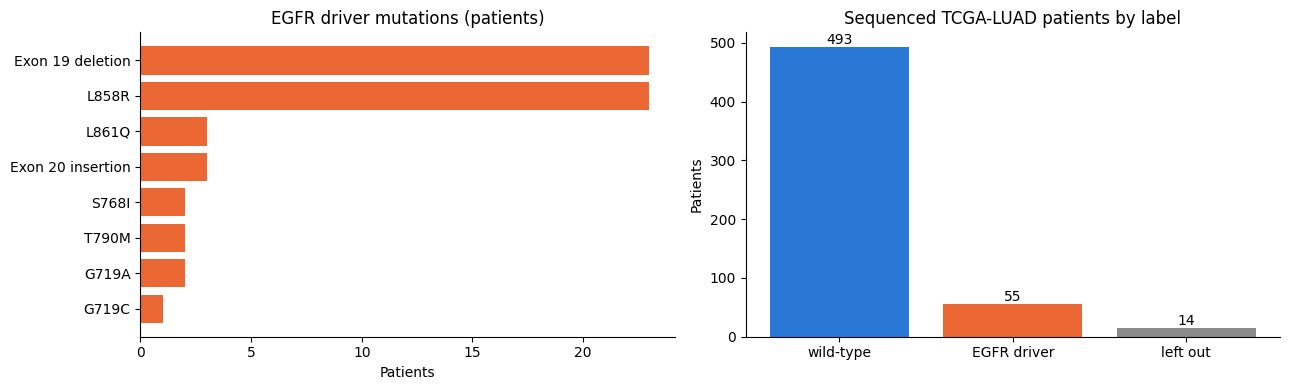

EGFR variants I left out as unclear (top 10):
HGVSp_Short         Variant_Classification
p.E709_T710delinsD  In_Frame_Del              3
p.L62R              Missense_Mutation         2
p.D1083Efs*11       Frame_Shift_Del           1
p.E866K             Missense_Mutation         1
p.G627*             Nonsense_Mutation         1
p.G721V             Missense_Mutation         1
p.E545Q             Missense_Mutation         1
p.G901V             Missense_Mutation         1
p.I759N             Missense_Mutation         1
p.K754E             Missense_Mutation         1
Name: count, dtype: int64


In [10]:
# What do the driver mutations look like? And what did I leave out?
driver_rows = egfr[egfr['egfr_class'] == 'driver'].copy()
driver_rows['group'] = np.where(driver_rows['Variant_Classification'] == 'In_Frame_Del', 'Exon 19 deletion',
                        np.where(driver_rows['Variant_Classification'] == 'In_Frame_Ins', 'Exon 20 insertion',
                                 driver_rows['HGVSp_Short'].str.replace('p.', '', regex=False)))
driver_counts = driver_rows.drop_duplicates(['patient', 'group'])['group'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(driver_counts.index[::-1], driver_counts.values[::-1], color=C_MUT)
axes[0].set_title('EGFR driver mutations (patients)')
axes[0].set_xlabel('Patients')

label_counts = patients['egfr_label'].value_counts().reindex([0, 1, -1]).fillna(0)
axes[1].bar(['wild-type', 'EGFR driver', 'left out'], label_counts.values, color=[C_WT, C_MUT, C_GRAY])
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v, str(int(v)), ha='center', va='bottom')
axes[1].set_title('Sequenced TCGA-LUAD patients by label')
axes[1].set_ylabel('Patients')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('EGFR variants I left out as unclear (top 10):')
print(egfr[egfr['egfr_class'] == 'other'][['HGVSp_Short', 'Variant_Classification']].value_counts().head(10))

**What the cleaning changed:** 55 patients have a real EGFR driver mutation, compared with 75 who have any EGFR change at all. The most common drivers are exon 19 deletions and L858R (23 patients each), which matches what I read about EGFR in lung adenocarcinoma. 14 patients had EGFR changes I couldn't classify, so I left them out instead of guessing.

---
# Part 2: Choosing the Slides

I query the GDC API for every open-access TCGA-LUAD **diagnostic** slide (the `DX` slides, which are the higher-quality FFPE scans), keep one slide per patient, and join them with the labels.

**Why I enrich mutant cases:** EGFR drivers are uncommon in TCGA-LUAD, so a random sample of 75 slides would contain only a handful of positives, and the model would have almost nothing to learn from. I take up to 25 driver-positive patients and 50 wild-type patients. This changes the positive rate in my data (about 1 in 3) compared with the real TCGA cohort, which I need to keep in mind: AUROC is not affected by this, but numbers like precision would be.

In [11]:
GDC_FILES = 'https://api.gdc.cancer.gov/files'
GDC_DATA = 'https://api.gdc.cancer.gov/data'

def query_gdc_diagnostic_slides(project='TCGA-LUAD'):
    # Returns one row per open-access diagnostic slide in the project
    filters = {'op': 'and', 'content': [
        {'op': 'in', 'content': {'field': 'cases.project.project_id', 'value': [project]}},
        {'op': 'in', 'content': {'field': 'data_type', 'value': ['Slide Image']}},
        {'op': 'in', 'content': {'field': 'experimental_strategy', 'value': ['Diagnostic Slide']}},
        {'op': 'in', 'content': {'field': 'access', 'value': ['open']}},
    ]}
    params = {'filters': json.dumps(filters),
              'fields': 'file_id,file_name,file_size,md5sum,cases.submitter_id',
              'format': 'JSON', 'size': '5000'}
    r = requests.get(GDC_FILES, params=params, timeout=120)
    r.raise_for_status()
    rows = []
    for h in r.json()['data']['hits']:
        rows.append({'file_id': h.get('file_id', h.get('id')),
                     'file_name': h['file_name'],
                     'file_size': int(h['file_size']),
                     'patient': h['cases'][0]['submitter_id']})
    return pd.DataFrame(rows)

def load_manifest_fallback(path):
    # Same columns, built from a GDC portal manifest file
    m = pd.read_csv(path, sep='\t')
    return pd.DataFrame({'file_id': m['id'], 'file_name': m['filename'],
                         'file_size': m['size'].astype(int),
                         'patient': m['filename'].str[:12]})

def download_slide(file_id, file_name, expected_size, out_dir=SLIDE_TMP, attempts=5):
    # Retries on failure, and checks the file size to catch half-finished downloads
    path = os.path.join(out_dir, file_name)
    if os.path.exists(path) and os.path.getsize(path) == expected_size:
        return path
    session = requests.Session()
    retry = Retry(total=5, connect=5, read=5, backoff_factor=3,
                  status_forcelist=[429, 500, 502, 503, 504], allowed_methods=['GET'])
    session.mount('https://', HTTPAdapter(max_retries=retry))
    for attempt in range(1, attempts + 1):
        try:
            with session.get(f'{GDC_DATA}/{file_id}', stream=True, timeout=(30, 300)) as r:
                r.raise_for_status()
                with open(path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)
            if os.path.getsize(path) == expected_size:
                return path
            print(f'Size mismatch on {file_name}, retrying')
        except Exception as e:
            print(f'Download error on {file_name} (attempt {attempt}): {e}')
            time.sleep(10 * attempt)
        if os.path.exists(path):
            os.remove(path)
    raise RuntimeError(f'Failed to download {file_name}')

In [12]:
try:
    slides_all = query_gdc_diagnostic_slides()
    print('Diagnostic slides from the GDC API:', len(slides_all))
except Exception as e:
    assert FULL_MANIFEST_PATH, f'GDC API failed ({e}). Set FULL_MANIFEST_PATH to a full manifest.'
    slides_all = load_manifest_fallback(FULL_MANIFEST_PATH)
    print('Diagnostic slides from the manifest:', len(slides_all))

slides_all = slides_all[slides_all['file_name'].str.contains('-DX')]
# One slide per patient: sorting by name puts DX1 first
slides_all = slides_all.sort_values('file_name').drop_duplicates('patient')

cohort = slides_all.merge(patients, on='patient', how='inner')
cohort = cohort[cohort['egfr_label'] >= 0]
print('Patients with a slide and a clean label:')
print(cohort['egfr_label'].value_counts().rename({0: 'wild-type', 1: 'EGFR driver'}))

pos = cohort[cohort['egfr_label'] == 1]
neg = cohort[cohort['egfr_label'] == 0]
selected = pd.concat([
    pos.sample(min(N_POS, len(pos)), random_state=SELECTION_SEED),
    neg.sample(min(N_NEG, len(neg)), random_state=SELECTION_SEED),
]).reset_index(drop=True)
selected['slide_id'] = selected['file_name'].str.replace('.svs', '', regex=False)
selected = selected.rename(columns={'egfr_label': 'egfr_mutant'})

# One slide per patient, so a split by slide is also a split by patient
assert selected['patient'].is_unique
selected.to_csv(f'{WORK}/selected_slides.csv', index=False)

print(f'\nSelected {len(selected)} slides: {selected.egfr_mutant.sum()} EGFR driver, '
      f'{(selected.egfr_mutant == 0).sum()} wild-type')
print(f'Total download size: {selected.file_size.sum() / 1e9:.1f} GB (one slide on disk at a time)')

Diagnostic slides from the GDC API: 541
Patients with a slide and a clean label:
egfr_label
wild-type      409
EGFR driver     46
Name: count, dtype: int64

Selected 75 slides: 25 EGFR driver, 50 wild-type
Total download size: 58.9 GB (one slide on disk at a time)


In [13]:
# A first look at the slides: how big are the files I'm about to download?
sizes = selected['file_size'] / 1e9
print(f'Selected slides: {len(selected)} | file size: median {sizes.median():.2f} GB, largest {sizes.max():.2f} GB')
print('Label per selected slide:', selected['egfr_mutant'].value_counts().rename({0: 'wild-type', 1: 'EGFR driver'}).to_dict())
display(selected[['slide_id', 'patient', 'egfr_mutant']].head())

Selected slides: 75 | file size: median 0.57 GB, largest 4.09 GB
Label per selected slide: {'wild-type': 50, 'EGFR driver': 25}


,slide_id,patient,egfr_mutant
0,TCGA-75-6207-01Z-00-DX1.837B7B0F-424C-423B-904...,TCGA-75-6207,1
1,TCGA-67-3772-01Z-00-DX1.CB05C5CC-2801-4BB9-94A...,TCGA-67-3772,1
2,TCGA-78-7147-01Z-00-DX1.a9fd2c5d-b8f3-4524-bd6...,TCGA-78-7147,1
3,TCGA-38-6178-01Z-00-DX1.5932337D-BA2B-455D-9E3...,TCGA-38-6178,1
4,TCGA-50-6591-01Z-00-DX1.12e1050b-75e9-4059-b94...,TCGA-50-6591,1


---
# Part 3: Finding Tissue and Tiling at Two Magnifications

**Tissue detection.** Same idea as in my prostate notebook: I make a small grayscale thumbnail of each slide, where every pixel is one brightness number from 0 (black) to 255 (white). Glass is almost white, so every pixel darker than 220 counts as tissue. I also drop pixels darker than 50, which are almost always black pen marks, not tissue. That gives me a yes/no **tissue mask**, and I check each square of the grid against it.

**Two magnifications.** Slides are scanned at 20x or 40x, so a fixed pyramid "level" means different zoom on different slides. I read tiles by **magnification** instead:

- **5x regions:** the whole tissue area split into a grid of 256 px tiles at 5x (a region is kept if it is at least 50% tissue). This is the "look at the whole slide" view.
- **20x tiles:** inside every 5x region, I sample up to 4 tiles at 20x. Each 5x region covers a 4 x 4 grid of 20x tiles, so each 20x tile remembers which region it came from.

The 20x tiles are what the model in this notebook uses. The 5x regions and the region links are for my agent notebook, where the agent looks at 5x first and then decides where to zoom in.

**Why sample across the whole slide:** if I kept only the first tiles while scanning from the top, the bottom of the slide would never be seen. Sampling from every region gives the whole section an equal chance.

In [14]:
MASK_DS = 32   # the tissue mask is built at 1/32 of full resolution

def get_base_mag(slide):
    # Scanner magnification of level 0 (usually 20 or 40)
    for key in ('openslide.objective-power', 'aperio.AppMag'):
        v = slide.properties.get(key)
        if v:
            try:
                return float(v)
            except ValueError:
                pass
    mpp = slide.properties.get('openslide.mpp-x')
    if mpp:
        return round(10 / float(mpp))      # 0.25 microns/pixel is about 40x
    print('  Warning: magnification unknown, assuming 40x')
    return 40.0

def tissue_mask(slide):
    # A small grayscale picture: glass is near-white, tissue is darker, pen marks are near-black
    W, H = slide.dimensions
    thumb = slide.get_thumbnail((W // MASK_DS, H // MASK_DS)).convert('RGB')
    gray = np.array(thumb.convert('L'))                 # one brightness number per pixel
    mask = (gray < GRAY_CUTOFF) & (gray > 50)           # True = tissue
    scale = (W / gray.shape[1], H / gray.shape[0])      # full-size pixels per mask pixel
    return mask, np.array(thumb), scale

def tissue_fraction(mask, scale, x0, y0, size0):
    # What share of a square (given in full-size pixels) is tissue, looked up on the mask
    sx, sy = scale
    top, bottom = int(y0 / sy), int((y0 + size0) / sy)
    left, right = int(x0 / sx), int((x0 + size0) / sx)
    patch = mask[top:bottom, left:right]
    if patch.size == 0:
        return 0.0
    return float(patch.mean())

def read_tile(slide, x0, y0, size0, out=TILE):
    # Reads a square of size0 level-0 pixels and returns it as out x out RGB
    level = slide.get_best_level_for_downsample(size0 / out)
    read = int(round(size0 / slide.level_downsamples[level]))
    img = slide.read_region((int(x0), int(y0)), level, (read, read)).convert('RGB')
    if read != out:
        img = img.resize((out, out), Image.BILINEAR)
    return np.array(img)

def tile_slide_two_mags(slide, mask, scale, base_mag, rng):
    low0 = int(round(TILE * base_mag / LOW_MAG))    # a 5x tile, in level-0 pixels
    hi0 = int(round(TILE * base_mag / HIGH_MAG))    # a 20x tile, in level-0 pixels
    W, H = slide.dimensions

    regions = [(x, y) for y in range(0, H - low0 + 1, low0) for x in range(0, W - low0 + 1, low0)
               if tissue_fraction(mask, scale, x, y, low0) >= MIN_TISSUE]
    if len(regions) > MAX_REGIONS:
        keep = np.sort(rng.choice(len(regions), MAX_REGIONS, replace=False))
        regions = [regions[i] for i in keep]

    n_sub = low0 // hi0
    hi_coords, hi_parent = [], []
    for r_idx, (x, y) in enumerate(regions):
        cands = [(x + i * hi0, y + j * hi0) for j in range(n_sub) for i in range(n_sub)
                 if tissue_fraction(mask, scale, x + i * hi0, y + j * hi0, hi0) >= MIN_TISSUE]
        if not cands:   # region passed as a whole, but no single sub-tile did
            cands = [(x + (n_sub // 2) * hi0, y + (n_sub // 2) * hi0)]
        for k in rng.choice(len(cands), min(HI_PER_REGION, len(cands)), replace=False):
            hi_coords.append(cands[k])
            hi_parent.append(r_idx)
    return regions, low0, hi_coords, hi_parent, hi0

Base magnification: 20x | 5x regions: 242 | 20x tiles: 968


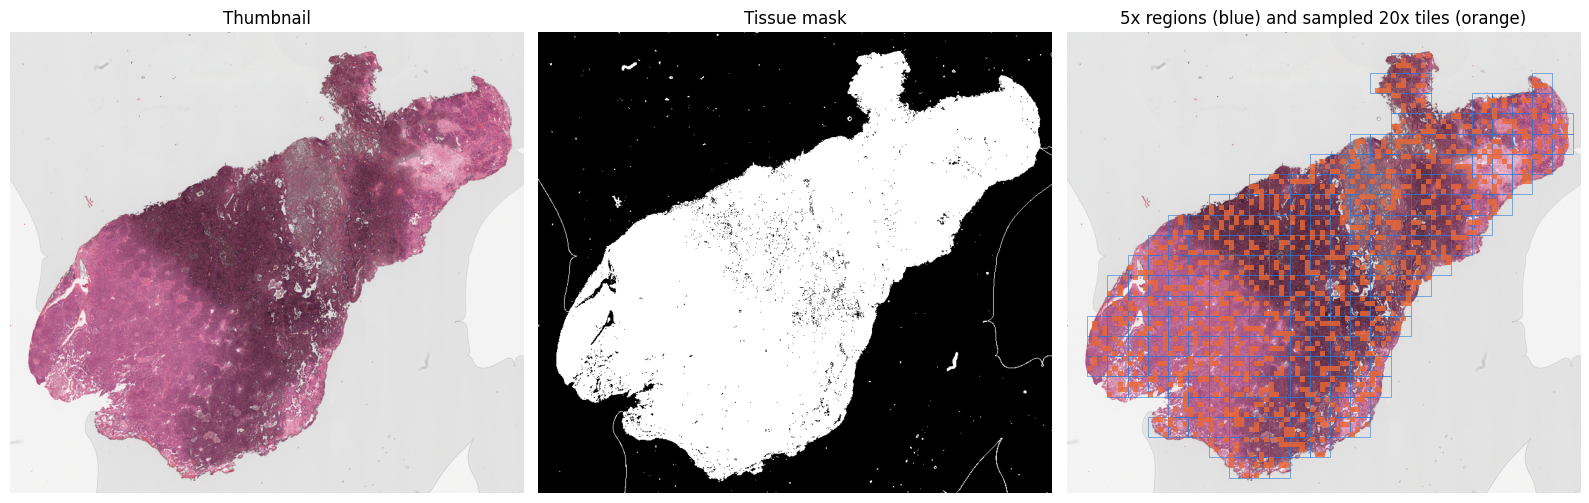

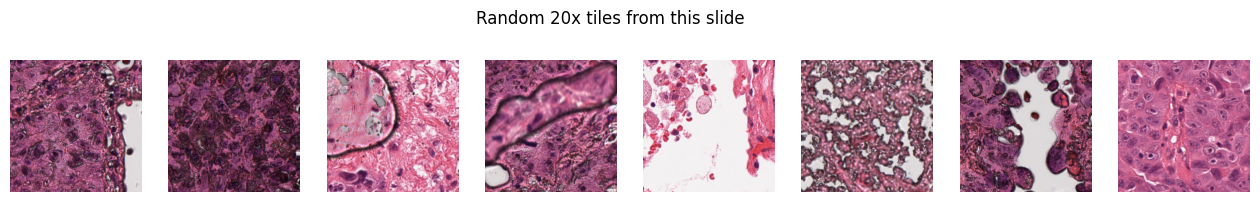

In [15]:
# Visual check on one slide before running everything
row = selected.iloc[0]
path = download_slide(row.file_id, row.file_name, row.file_size)
slide = openslide.OpenSlide(path)
base_mag = get_base_mag(slide)
mask, thumb, scale = tissue_mask(slide)
regions, low0, hi_coords, hi_parent, hi0 = tile_slide_two_mags(slide, mask, scale, base_mag, np.random.default_rng(0))
print(f'Base magnification: {base_mag:.0f}x | 5x regions: {len(regions)} | 20x tiles: {len(hi_coords)}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(thumb); axes[0].set_title('Thumbnail')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Tissue mask')
axes[2].imshow(thumb); axes[2].set_title('5x regions (blue) and sampled 20x tiles (orange)')
sx, sy = scale
for (x, y) in regions:
    axes[2].add_patch(mpatches.Rectangle((x / sx, y / sy), low0 / sx, low0 / sy, fill=False, ec=C_WT, lw=0.4))
for (x, y) in hi_coords:
    axes[2].add_patch(mpatches.Rectangle((x / sx, y / sy), hi0 / sx, hi0 / sy, fill=True, fc=C_MUT, ec='none', alpha=0.8))
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
for ax, k in zip(axes, np.random.default_rng(1).choice(len(hi_coords), 8, replace=False)):
    ax.imshow(read_tile(slide, *hi_coords[k], hi0)); ax.axis('off')
plt.suptitle('Random 20x tiles from this slide')
plt.show()
slide.close()

**What I see:** the mask covers the tissue and skips the glass, and the 5x regions and 20x tiles are spread across the whole section. Some tiles land on blood, empty air spaces, or the edge of black pen lines, which the mask still counts as tissue. I note this as a limitation.

---
# Part 4: The Patch Encoder

My prostate baseline used a ResNet-18 trained on ImageNet photos. It knows edges and textures, but it has never seen tissue. Here I use **Phikon** (Owkin), a Vision Transformer pretrained with self-supervised learning on millions of histology tiles from TCGA. No labels were used in its pretraining, so it doesn't know anything about EGFR. It has only learned what tissue looks like. Each tile becomes a 768-number vector.



In [16]:
class TileEncoder:
    def __init__(self, name):
        self.name = name
        if name == 'phikon':
            from transformers import ViTModel
            self.model = ViTModel.from_pretrained('owkin/phikon', add_pooling_layer=False)
            self.dim = 768
        else:
            self.model = models.resnet18(weights='IMAGENET1K_V1')
            self.model.fc = nn.Identity()
            self.dim = 512
        self.model.eval().to(device)
        self.preprocess = T.Compose([
            T.ToTensor(),
            T.Resize(224, antialias=True),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    @torch.no_grad()
    def __call__(self, tiles):
        x = torch.stack([self.preprocess(t) for t in tiles]).to(device)
        with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            if self.name == 'phikon':
                out = self.model(pixel_values=x).last_hidden_state[:, 0, :]   # the [CLS] token
            else:
                out = self.model(x)
        return out.float().cpu()

encoder = TileEncoder(ENCODER_NAME)
print(f'Encoder: {ENCODER_NAME}, {encoder.dim} numbers per tile')

def embed_coords(slide, coords, size0, batch_size=64):
    # Reads and embeds tiles in small batches, so thousands of tiles never sit in memory at once
    out = []
    for i in range(0, len(coords), batch_size):
        tiles = [read_tile(slide, x, y, size0) for (x, y) in coords[i:i + batch_size]]
        out.append(encoder(tiles))
    return torch.cat(out).half()   # float16 halves the disk space

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: owkin/phikon
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.bias   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder: phikon, 768 numbers per tile


---
# Part 5: Download, Tile, Embed, Delete

My 75 slides add up to 58.9 GB, so I can't keep them all on Kaggle's disk. For each slide I download it, find the tissue, embed the 5x regions and the 20x tiles, save the embeddings with their coordinates, save a small thumbnail, and then delete the slide. If the session stops, re-running this cell skips every slide that is already cached.

This is the slow step (a few hours). The cached embeddings, thumbnails and models are saved as this notebook's output, and my agent notebook starts from them.

In [17]:
def process_slide(row):
    out_path = os.path.join(CACHE_DIR, f'{row.slide_id}.pt')
    if os.path.exists(out_path):
        return 'cached'
    path = download_slide(row.file_id, row.file_name, row.file_size)
    slide = openslide.OpenSlide(path)
    try:
        base_mag = get_base_mag(slide)
        mask, thumb, scale = tissue_mask(slide)
        rng = np.random.default_rng(zlib.crc32(row.slide_id.encode()))   # same tiles every run
        regions, low0, hi_coords, hi_parent, hi0 = tile_slide_two_mags(slide, mask, scale, base_mag, rng)
        if len(regions) == 0:
            return 'no tissue'
        Image.fromarray(thumb).save(os.path.join(THUMB_DIR, f'{row.slide_id}.png'))
        torch.save({
            'low_emb': embed_coords(slide, regions, low0),
            'low_coords': torch.tensor(regions),
            'hi_emb': embed_coords(slide, hi_coords, hi0),
            'hi_coords': torch.tensor(hi_coords),
            'hi_parent': torch.tensor(hi_parent),
            'low_size0': low0, 'hi_size0': hi0,
            'base_mag': base_mag, 'thumb_scale': scale,
            'mask': torch.from_numpy(mask),
        }, out_path)
        return 'done'
    finally:
        slide.close()
        if not KEEP_SLIDES and os.path.exists(path):
            os.remove(path)

status = {}
for row in tqdm(selected.itertuples(), total=len(selected), desc='Slides'):
    try:
        status[row.slide_id] = process_slide(row)
    except Exception as e:
        status[row.slide_id] = f'error: {e}'
        print(f'{row.slide_id}: {e}')
print(pd.Series(status).value_counts())

Slides:   0%|          | 0/75 [00:00<?, ?it/s]

done    75
Name: count, dtype: int64


Slides ready: 75 (25 EGFR driver)
Scanner magnification: {40.0: np.int64(67), 20.0: np.int64(8)}


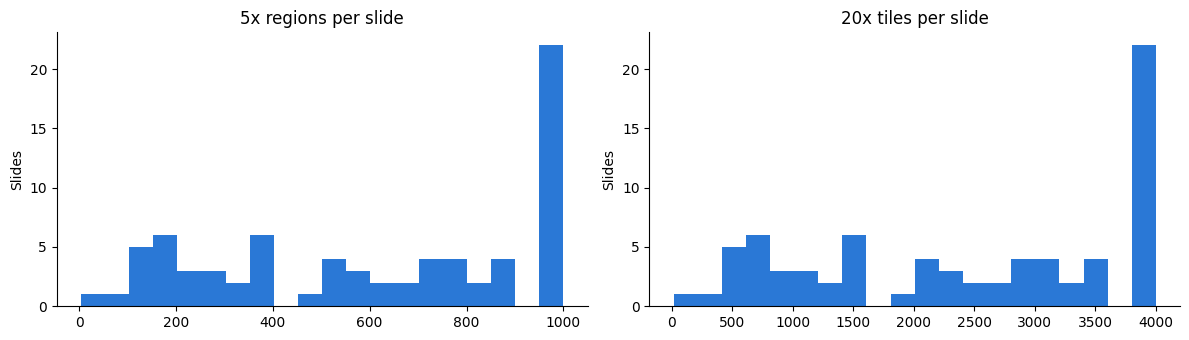

In [18]:
# Load every cached slide into memory (float16 keeps this small)
cache = {}
for sid in selected['slide_id']:
    p = os.path.join(CACHE_DIR, f'{sid}.pt')
    if os.path.exists(p):
        cache[sid] = torch.load(p)

data = selected[selected['slide_id'].isin(cache)].reset_index(drop=True)
print(f'Slides ready: {len(data)} ({data.egfr_mutant.sum()} EGFR driver)')

n_hi = [len(cache[s]['hi_emb']) for s in data.slide_id]
n_low = [len(cache[s]['low_emb']) for s in data.slide_id]
mags = pd.Series([cache[s]['base_mag'] for s in data.slide_id]).value_counts()
print('Scanner magnification:', dict(mags))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(n_low, bins=20, color=C_WT); axes[0].set_title('5x regions per slide')
axes[1].hist(n_hi, bins=20, color=C_WT); axes[1].set_title('20x tiles per slide')
for ax in axes:
    ax.set_ylabel('Slides'); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
# Part 6: The Model, CLAM-Style Gated Attention-MIL

I only have one label per slide, but thousands of tiles. Attention-MIL solves this by learning **how much each tile should count**:

1. Each tile's 768 numbers are compressed to 256 by a small layer.
2. An **attention score** is computed for every tile. The tiles' scores are turned into weights that add up to 1 (softmax).
3. The slide is summarized as the **weighted average** of its tiles, and a final layer turns that summary into one EGFR prediction.

**What "gated" means.** In basic attention-MIL (Ilse et al., 2018), the score comes from one branch with a tanh. Gated attention (Ilse et al., 2018; used in CLAM, Lu et al., 2021) adds a second branch with a sigmoid, and multiplies the two. The sigmoid branch acts like a gate between 0 and 1 that can switch a tile's contribution down. In practice this makes the attention more selective.

**What I didn't include from CLAM:** CLAM also has an extra "instance clustering" loss that pushes high- and low-attention tiles apart. I left it out to keep the model simple, so I call this "CLAM-style," not CLAM.

The attention weights are also my interpretability tool: they show which tiles the model relied on (Part 8), and my agent notebook uses them to decide where to zoom in.

In [19]:
class GatedAttentionMIL(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, attn_dim=128, dropout=0.25):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.attn_tanh = nn.Sequential(nn.Linear(hidden_dim, attn_dim), nn.Tanh(), nn.Dropout(dropout))
        self.attn_gate = nn.Sequential(nn.Linear(hidden_dim, attn_dim), nn.Sigmoid(), nn.Dropout(dropout))
        self.attn_score = nn.Linear(attn_dim, 1)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, bag):
        # bag: (num_tiles, in_dim), all tiles of one slide
        h = self.proj(bag)                                                    # (N, 256)
        scores = self.attn_score(self.attn_tanh(h) * self.attn_gate(h)).squeeze(-1)  # (N,)
        weights = torch.softmax(scores, dim=0)                                # sum to 1
        slide_vector = (weights.unsqueeze(-1) * h).sum(dim=0)                 # (256,)
        logit = self.classifier(slide_vector).squeeze(-1)
        return logit, weights

# Shape check before training
m = GatedAttentionMIL(encoder.dim).to(device)
bag = cache[data.slide_id[0]]['hi_emb'].float().to(device)
logit, w = m(bag)
print('logit shape (expect scalar):', tuple(logit.shape), '| weights:', tuple(w.shape), '| weights sum:', round(w.sum().item(), 4))

logit shape (expect scalar): () | weights: (968,) | weights sum: 1.0


---
# Part 7: Evaluating the Model

Every slide must be judged by a model that never saw it during training. I use **5-fold cross-validation**:

1. Split the slides into 5 equal groups (folds), each with the same mix of mutant and wild-type slides.
2. Train a model on 4 folds, and use it to predict the 5th fold, which it has never seen.
3. Repeat 5 times, so each fold gets predicted once.

At the end, every slide has exactly one honest prediction, and I compute **one AUROC over all slides**. The number of epochs (30) is fixed in advance, so I never pick the "best" epoch by looking at the results. I also compute a **95% confidence interval**, which shows how much the AUROC could move just by chance.

Two details that matter more here than in my prostate notebook:

- **Mutant slides are the smaller group** (about 1 in 3), so the loss counts each mutant slide more (`pos_weight` = wild-type count / mutant count in the training folds). Otherwise the model could do well by mostly guessing "wild-type."
- **Slides have thousands of tiles**, so each training step uses a random 512 of them. That keeps training fast, and the model sees a slightly different part of each slide every time, which helps it not memorize the slides. At prediction time it uses all tiles.

In [20]:
def get_bag(sid, n_tiles=None, gen=None):
    # All 20x tile embeddings of one slide, or a random n_tiles of them during training
    bag = cache[sid]['hi_emb']
    if n_tiles is not None and len(bag) > n_tiles:
        bag = bag[torch.randperm(len(bag), generator=gen)[:n_tiles]]
    return bag.float().to(device)

def train_model(train_ids, train_labels):
    set_seed(SEED)
    gen = torch.Generator().manual_seed(SEED)
    model = GatedAttentionMIL(encoder.dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    n_pos = max(int(train_labels.sum()), 1)
    pos_weight = torch.tensor((len(train_labels) - n_pos) / n_pos, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for epoch in range(EPOCHS):
        model.train()
        for i in torch.randperm(len(train_ids), generator=gen).tolist():
            logit, _ = model(get_bag(train_ids[i], TILES_PER_STEP, gen))
            loss = criterion(logit, torch.tensor(float(train_labels[i]), device=device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

@torch.no_grad()
def predict(model, ids):
    model.eval()
    return np.array([torch.sigmoid(model(get_bag(s))[0]).item() for s in ids])

def bootstrap_auroc(y_true, y_prob, n=2000):
    # Re-draw the slides with replacement 2000 times and recompute the AUROC each time
    rng = np.random.default_rng(SEED)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) == 2:
            scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(scores, [2.5, 97.5])

In [21]:
ids = data['slide_id'].values
y = data['egfr_mutant'].values.astype(int)

oof = np.zeros(len(ids))                 # one held-out prediction per slide
fold_of = np.zeros(len(ids), dtype=int)  # which fold each slide was held out in
fold_models = {}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for k, (train_idx, test_idx) in enumerate(skf.split(ids, y)):
    model = train_model(ids[train_idx], y[train_idx])
    oof[test_idx] = predict(model, ids[test_idx])
    fold_of[test_idx] = k
    fold_models[k] = model.eval()
    print(f'Fold {k + 1}: trained on {len(train_idx)} slides, predicted {len(test_idx)} '
          f'({int(y[test_idx].sum())} mutant)')

auroc = roc_auc_score(y, oof)
lo, hi = bootstrap_auroc(y, oof)
print(f'\nOut-of-fold AUROC: {auroc:.3f}  (95% confidence interval: {lo:.3f} to {hi:.3f})')

Fold 1: trained on 60 slides, predicted 15 (5 mutant)
Fold 2: trained on 60 slides, predicted 15 (5 mutant)
Fold 3: trained on 60 slides, predicted 15 (5 mutant)
Fold 4: trained on 60 slides, predicted 15 (5 mutant)
Fold 5: trained on 60 slides, predicted 15 (5 mutant)

Out-of-fold AUROC: 0.650  (95% confidence interval: 0.514 to 0.781)


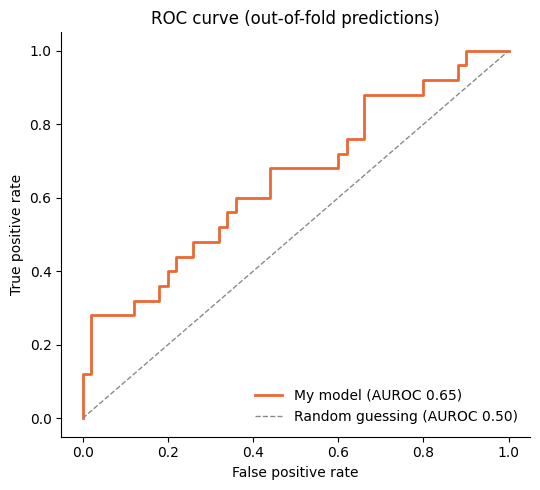

In [22]:
fpr, tpr, _ = roc_curve(y, oof)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=C_MUT, lw=2, label=f'My model (AUROC {auroc:.2f})')
ax.plot([0, 1], [0, 1], color=C_GRAY, lw=1, ls='--', label='Random guessing (AUROC 0.50)')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve (out-of-fold predictions)')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What the numbers mean:** the model reached an out-of-fold AUROC of 0.65, with a 95% confidence interval of 0.51 to 0.78. So if I pick one EGFR-mutant and one wild-type slide, the model ranks the mutant one higher about 65% of the time. The lower end of the interval is only just above 0.5, because I have only 25 mutant slides, so I read this as a weak signal that is probably real, not as a precise number. Published work on this task uses many more slides.

---
# Part 8: Where Does the Model Look?

For two slides, I take the model from the fold where that slide was **held out** (so the model never trained on it) and draw its attention on the thumbnail. Each 20x tile's weight is added to the 5x region it came from, so the heatmap shows which areas of the slide mattered most. This region-level map is exactly what my agent will use to decide where to zoom in.

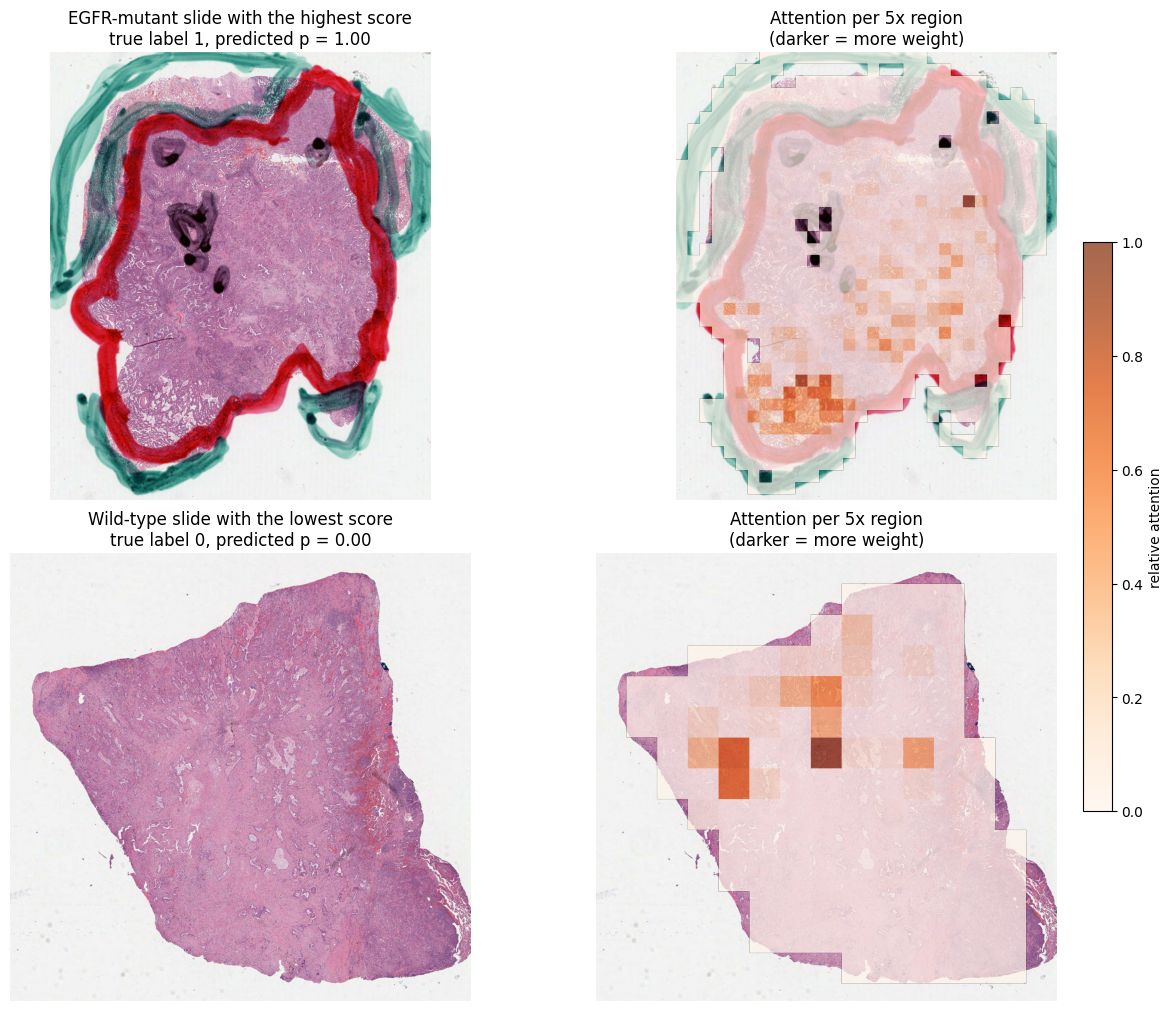

In [23]:
@torch.no_grad()
def region_attention(sid):
    # Uses the model from the fold where this slide was held out
    i = int(np.where(ids == sid)[0][0])
    model = fold_models[fold_of[i]]
    _, w = model(get_bag(sid))
    parent = cache[sid]['hi_parent'].numpy()
    region_w = np.bincount(parent, weights=w.cpu().numpy(), minlength=len(cache[sid]['low_coords']))
    return region_w, w.cpu().numpy()

def plot_attention(sid, ax_thumb, ax_heat):
    c = cache[sid]
    thumb = np.array(Image.open(os.path.join(THUMB_DIR, f'{sid}.png')))
    sx, sy = c['thumb_scale']
    region_w, _ = region_attention(sid)
    heat = np.full(thumb.shape[:2], np.nan)
    for (x, y), wv in zip(c['low_coords'].tolist(), region_w / region_w.max()):
        heat[int(y / sy):int((y + c['low_size0']) / sy), int(x / sx):int((x + c['low_size0']) / sx)] = wv
    ax_thumb.imshow(thumb)
    ax_heat.imshow(thumb)
    im = ax_heat.imshow(heat, cmap='Oranges', alpha=0.7, vmin=0, vmax=1)
    for ax in (ax_thumb, ax_heat):
        ax.axis('off')
    return im

true_mut = np.where(y == 1)[0]
true_wt = np.where(y == 0)[0]
examples = {'EGFR-mutant slide with the highest score': ids[true_mut[np.argmax(oof[true_mut])]],
            'Wild-type slide with the lowest score': ids[true_wt[np.argmin(oof[true_wt])]]}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for r, (title, sid) in enumerate(examples.items()):
    im = plot_attention(sid, axes[r, 0], axes[r, 1])
    i = int(np.where(ids == sid)[0][0])
    axes[r, 0].set_title(f'{title}\ntrue label {y[i]}, predicted p = {oof[i]:.2f}')
    axes[r, 1].set_title('Attention per 5x region\n(darker = more weight)')
fig.colorbar(im, ax=axes[:, 1], shrink=0.6, label='relative attention')
plt.show()

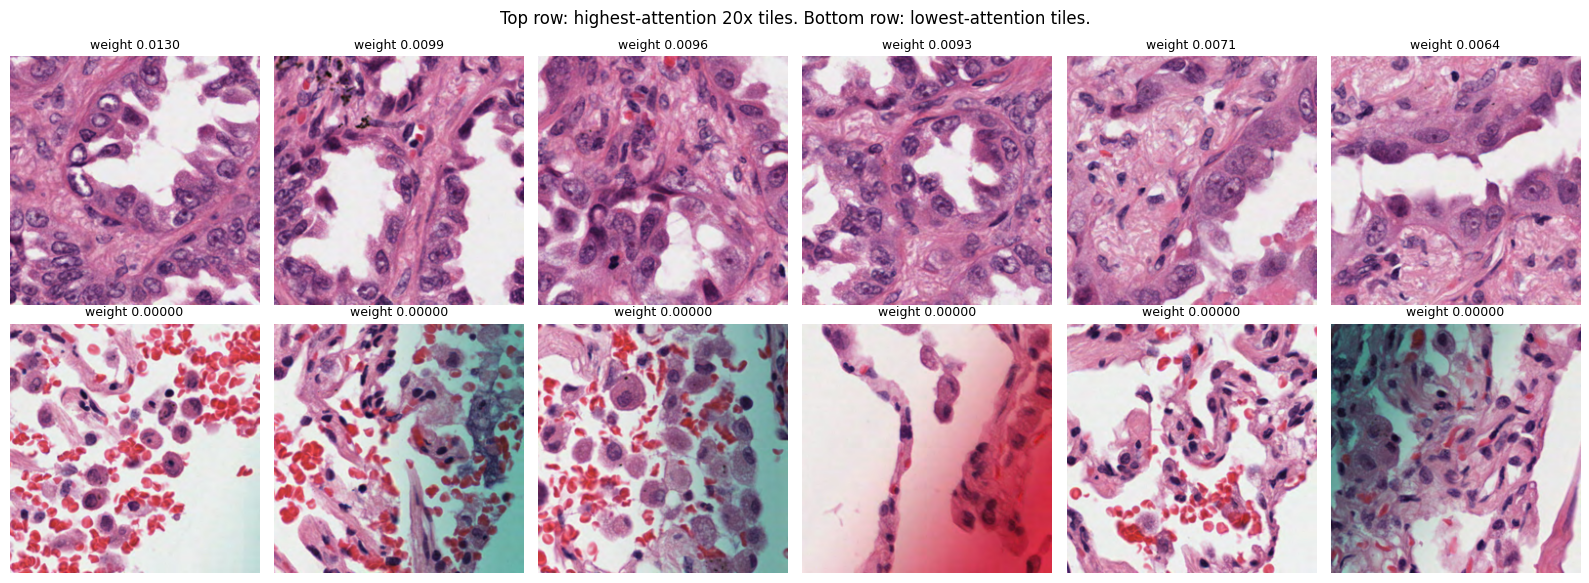

In [24]:
# Look at the actual top-attention tiles. The slide was deleted after caching,
# so I download this one slide again (about a minute).
sid = examples['EGFR-mutant slide with the highest score']
row = data[data.slide_id == sid].iloc[0]
path = download_slide(row.file_id, row.file_name, row.file_size)
slide = openslide.OpenSlide(path)
_, tile_w = region_attention(sid)
order = np.argsort(-tile_w)
coords, hi0 = cache[sid]['hi_coords'].tolist(), cache[sid]['hi_size0']

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, k in zip(axes[0], order[:6]):
    ax.imshow(read_tile(slide, *coords[k], hi0)); ax.set_title(f'weight {tile_w[k]:.4f}', fontsize=9); ax.axis('off')
for ax, k in zip(axes[1], order[-6:]):
    ax.imshow(read_tile(slide, *coords[k], hi0)); ax.set_title(f'weight {tile_w[k]:.5f}', fontsize=9); ax.axis('off')
plt.suptitle('Top row: highest-attention 20x tiles. Bottom row: lowest-attention tiles.')
plt.tight_layout()
plt.show()
slide.close()
if not KEEP_SLIDES:
    os.remove(path)

**What the attention shows:** on the mutant slide, the highest-attention tiles are tumor glands: crowded cells with large nuclei around open spaces. The lowest-attention tiles are blood, thin normal air-sac walls, and tiles covered by green or red pen ink, which get almost zero weight. So the model mostly ignores ink and blood and focuses on tumor. But attention shows where the model looked, not why it predicted EGFR, and the most confident mutant slide is also heavily pen-marked, so I can't fully rule out that the ink plays a role.

---
# Part 9: Saving Everything for the Agent Notebook

The agent notebook needs the cached embeddings, the fold assignments, and the per-fold models, so that each slide is always handled by a model that never trained on it.

In [25]:
out = data[['slide_id', 'patient', 'file_id', 'file_name', 'file_size', 'egfr_mutant']].copy()
out[f'oof_prob_seed{SEED}'] = oof
out[f'fold_seed{SEED}'] = fold_of
out.to_csv(f'{WORK}/oof_predictions.csv', index=False)

for k, model in fold_models.items():
    torch.save(model.state_dict(), f'{MODEL_DIR}/gated_attn_seed{SEED}_fold{k}.pt')

run_info = {'encoder': ENCODER_NAME, 'embed_dim': encoder.dim, 'low_mag': LOW_MAG, 'high_mag': HIGH_MAG,
            'tile': TILE, 'n_folds': N_FOLDS, 'seeds': [SEED], 'epochs': EPOCHS, 'lr': LR,
            'auroc': float(auroc), 'ci95': [float(lo), float(hi)],
            'n_slides': int(len(data)), 'n_pos': int(y.sum())}
with open(f'{WORK}/run_info.json', 'w') as f:
    json.dump(run_info, f, indent=2)
print(json.dumps(run_info, indent=2))

{
  "encoder": "phikon",
  "embed_dim": 768,
  "low_mag": 5,
  "high_mag": 20,
  "tile": 256,
  "n_folds": 5,
  "seeds": [
    0
  ],
  "epochs": 30,
  "lr": 0.0001,
  "auroc": 0.6504000000000001,
  "ci95": [
    0.5135879320987655,
    0.7807422222222222
  ],
  "n_slides": 75,
  "n_pos": 25
}


---
## Summary

I built an EGFR prediction pipeline with clean driver-mutation labels, 75 slides with mutant cases enriched, tiles sampled across the whole tissue at two magnifications, the Phikon pathology encoder, and CLAM-style gated attention. Under 5-fold cross-validation, the model reached an AUROC of 0.65 (95% confidence interval 0.51 to 0.78), a weak but probably real signal. The attention maps put the most weight on tumor glands and almost none on blood or pen ink.

## Honest Limitations

- **Still a small dataset.** 75 slides with 25 mutant cases gives a wide confidence interval. The number shows whether there is a signal, not how well this would work in a clinic.
- **Enriched positives.** About 1 in 3 of my slides is EGFR-mutant, higher than in the real cohort. AUROC is not affected, but precision and predictive values would be.
- **One institution-mixed public cohort, no external test set.** TCGA slides come from many hospitals, and the model could partly learn site or scanner differences. Phikon was also pretrained on TCGA images (without labels).
- **Sampled tiles.** Up to 4 tiles per 5x region and up to 1000 regions per slide, so the model does not see every tile.
- **Simple tissue detection.** A brightness cutoff removes glass and black ink, but colored pen marks, dust or folds can still count as tissue.
- **Attention is not an explanation.** It shows where the model put weight, not the biological reason for its prediction.

**One limitation I noticed myself:** many slides have red, green or black marker ink drawn around the tumor. My brightness mask counts colored ink as tissue, so ink tiles end up in the bags. Attention gives them almost no weight, but a color filter that removes ink before tiling would be cleaner, and it is the first thing I'd add.

## What's Next

In my next notebook, an **agent** uses this model's 5x attention to decide which regions of the slide to zoom into, instead of processing every tile. I compare it with using all tiles and with zooming into random regions, measuring both accuracy and how many tiles it needs.
